In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, root_mean_squared_error

sns.set_style()
sns.set_theme()

In [2]:
data = pd.read_csv('data/taxi_trip_pricing_sub.csv')
data

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,22.64,15.6180
...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,114.94,61.2090


In [3]:
data = data.dropna(ignore_index=True)

In [4]:
categorical_columns = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']
numerical_columns = ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare','Trip_Duration_Minutes']
target_col = 'Trip_Price'

target = data[target_col]

In [6]:
encoder = OneHotEncoder(sparse_output=False)
encoder.fit(data[categorical_columns])
encoded_array = encoder.transform(data[categorical_columns])


In [7]:
encoded_array

array([[0., 0., 1., ..., 1., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 1., 0., 0.],
       [0., 0., 1., ..., 1., 0., 0.]], shape=(627, 12))

In [8]:
encoder.get_feature_names_out(categorical_columns)

array(['Time_of_Day_Afternoon', 'Time_of_Day_Evening',
       'Time_of_Day_Morning', 'Time_of_Day_Night', 'Day_of_Week_Weekday',
       'Day_of_Week_Weekend', 'Traffic_Conditions_High',
       'Traffic_Conditions_Low', 'Traffic_Conditions_Medium',
       'Weather_Clear', 'Weather_Rain', 'Weather_Snow'], dtype=object)

In [10]:
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_columns), index=data.index)
encoded_df

,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekday,Day_of_Week_Weekend,Traffic_Conditions_High,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Clear,Weather_Rain,Weather_Snow
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
622,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
623,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
624,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
625,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [11]:

features = data.drop(columns=categorical_columns + [target_col]).join(encoded_df)

In [12]:
features

,Trip_Distance_km,Passenger_Count,Base_Fare,Trip_Duration_Minutes,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekday,Day_of_Week_Weekend,Traffic_Conditions_High,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Clear,Weather_Rain,Weather_Snow
0,19.35,3.0,3.56,53.82,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,36.87,1.0,2.70,37.27,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
2,8.64,2.0,2.55,89.33,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,3.85,4.0,3.51,5.05,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,41.79,3.0,4.60,86.95,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
622,5.49,4.0,2.39,58.39,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
623,45.95,4.0,3.12,61.96,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
624,7.70,3.0,2.08,54.18,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
625,47.56,1.0,2.67,114.94,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [13]:
lr = LinearRegression()
lr.fit(features, target)

LinearRegression()

In [14]:
lr.coef_

array([ 1.81615046,  1.57776007,  0.08763458,  0.32168605,  0.08126496,
       -0.64474754,  0.91762126, -0.35413868,  0.67351836, -0.67351836,
        0.93149718, -0.51424421, -0.41725297, -1.10076681, -2.43654577,
        3.53731257])

In [15]:
lr.feature_names_in_

array(['Trip_Distance_km', 'Passenger_Count', 'Base_Fare',
       'Trip_Duration_Minutes', 'Time_of_Day_Afternoon',
       'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night',
       'Day_of_Week_Weekday', 'Day_of_Week_Weekend',
       'Traffic_Conditions_High', 'Traffic_Conditions_Low',
       'Traffic_Conditions_Medium', 'Weather_Clear', 'Weather_Rain',
       'Weather_Snow'], dtype=object)

In [16]:
pd.Series(data=lr.coef_, index=lr.feature_names_in_)

Trip_Distance_km             1.816150
Passenger_Count              1.577760
Base_Fare                    0.087635
Trip_Duration_Minutes        0.321686
Time_of_Day_Afternoon        0.081265
Time_of_Day_Evening         -0.644748
Time_of_Day_Morning          0.917621
Time_of_Day_Night           -0.354139
Day_of_Week_Weekday          0.673518
Day_of_Week_Weekend         -0.673518
Traffic_Conditions_High      0.931497
Traffic_Conditions_Low      -0.514244
Traffic_Conditions_Medium   -0.417253
Weather_Clear               -1.100767
Weather_Rain                -2.436546
Weather_Snow                 3.537313
dtype: float64

In [18]:
predicted_values = lr.predict(features)
predicted_values

array([ 4.17058403e+01,  6.35063424e+01,  2.99252676e+01, -1.28613586e+00,
        9.20358002e+01,  1.88659244e+01,  2.01500747e+01,  5.67696429e+01,
        7.16480571e+01,  5.72647500e+01,  1.83569008e+02,  3.66070968e+01,
        2.67886556e+02,  1.72088093e+01,  7.72414170e+01,  4.52713322e+00,
        9.69684338e+01,  7.24938720e+01,  3.43177823e+01,  7.10851181e+01,
        6.03270911e+01,  2.13375153e+01,  6.00146860e+01,  2.63293470e+01,
        2.89947206e+01,  6.54155193e+01,  4.68526562e+01,  5.13995195e+01,
        5.24769255e+01,  9.75030869e+00,  6.41488039e+01,  8.03194333e+01,
        5.52026889e+01,  1.00738394e+02,  3.13921317e+01,  2.30297993e+01,
        5.61918468e+01,  5.03268666e+01,  5.78185568e+01,  2.71882315e+02,
        5.35826098e+01,  4.09445622e+01,  9.90880150e+01,  7.31365888e+01,
        3.72527863e+00,  8.18085177e+01,  8.39961473e+01,  3.76474924e+01,
        1.14744059e+00,  7.33852509e+01,  7.63941907e+01,  5.11864999e+01,
        2.18967446e+00,  

In [19]:
root_mean_squared_error(target, predicted_values)

20.001155768884132

In [20]:
r2_score(target, predicted_values)

0.795351122828345

<Axes: >

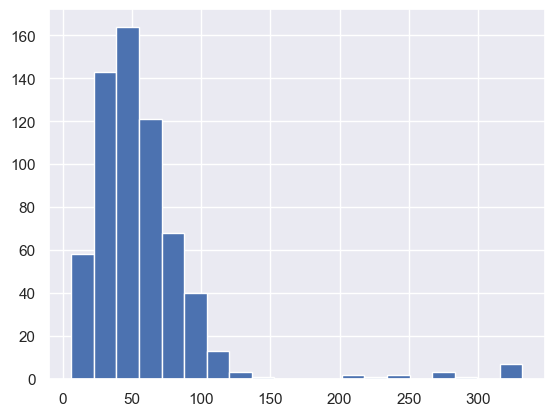

In [21]:
data[target_col].hist(bins=20)